In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
import ast
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow import keras


In [11]:
# -------------------------
# CONFIGURAÇÕES GERAIS
# -------------------------
PREDICTORS = ["PwmD", "PwmE"]
TARGET = ["Wd", "We"]
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 
TIME_STEPS = 5
NDATASETS = 4  # ajuste se houver mais datasets

In [12]:
# -------------------------
# LEITURA DOS DATASETS
# -------------------------
Datasets = []
for i in range(NDATASETS):
    Dataset = pd.read_csv(f"../Dados/TestData/Data{i + 1}.csv")
    Dataset.index = (np.arange(0, len(Dataset)) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head())

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7    0.0  0.0  0.0   3.28   3.28  68.95  68.95
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.0  0.0   3.02   3.02  63.44  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   

In [13]:
# -------------------------
# NORMALIZAÇÃO
# -------------------------
NormDatasets = []
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = pd.read_csv(f"../Dados/Data1.csv")
SCALER.fit(TrainDataset[PREDICTORS])
OUT_SCALER.fit(TrainDataset[TARGET])

for i in range(NDATASETS):
    CurrentTestDataset = Datasets[i].copy()

    CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
    CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])

    NormDatasets.append(CurrentTestDataset)
    print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
    print(NormDatasets[i].head())


++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.21  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.28  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.404730  1.141992
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.21  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.28  0.0  0.7    0.0  0.107454  0.09236 

In [14]:
# -------------------------
# FUNÇÃO PARA CRIAR SEQUÊNCIAS
# -------------------------
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i - timesteps:i].values)
        Y_seq.append(target_data.iloc[i].values)
    return np.array(X_seq), np.array(Y_seq)

# Odometria 

- R = 0.034    Raio da roda (m)
- L = 0.147/2  Distância entre rodas (m)
- T = 0.07     Período de amostragem (s)

- $x_{k+1} = x_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \cos(\theta_k)$

- $  y_{k+1} = y_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \sin(\theta_k)  $

- $ \theta_{k+1} = \theta_k + \frac{R . T}{2L} . (\phi_d[k] - \phi_e[k]) $



In [15]:
R = 0.032   
L = 0.124/2  
T = 0.07   

def Odometry(Wd, We, x0=0, y0=0.7, theta0=0):

    n = len(Wd)
    X_est, Y_est, Theta_est = [x0], [y0], [theta0]

    for k in range(n - 1):
        theta_k = Theta_est[-1]

        # Cinemática diferencial
        x_next = X_est[-1] + (R * T / 2) * (np.cos(theta_k) * (Wd[k] + We[k]))
        y_next = Y_est[-1] + (R * T / 2) * (np.sin(theta_k) * (Wd[k] + We[k]))
        theta_next = Theta_est[-1] + (R * T / (2 * L)) * (Wd[k] - We[k])

        X_est.append(x_next)
        Y_est.append(y_next)
        Theta_est.append(theta_next)

    return np.array(X_est), np.array(Y_est), np.array(Theta_est)



In [16]:
import matplotlib.pyplot as plt
import numpy as np

def PlotTrajectoryEvolution(X_true, Y_true, Theta_true, X_est, Y_est, Theta_est, title):
    """
    Exibe 3 gráficos discretos (X, Y, Θ) em função do tempo (ou iteração k).
    Cada gráfico mostra amostras reais e estimadas.
    """
    k = np.arange(len(X_true))
    time = (k * T).round(5)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # --- X ---
    axs[0].scatter(time, X_true, marker='o', s=15, label='X verdadeiro', color='blue', alpha=0.7)
    axs[0].scatter(time, X_est, marker='x', s=15, label='X estimado', color='red', alpha=0.7)
    axs[0].set_ylabel('X [m]')
    axs[0].legend()
    axs[0].grid(True)

    # --- Y ---
    axs[1].scatter(time, Y_true, marker='o', s=15, label='Y verdadeiro', color='blue', alpha=0.7)
    axs[1].scatter(time, Y_est, marker='x', s=15, label='Y estimado', color='red', alpha=0.7)
    axs[1].set_ylabel('Y [m]')
    axs[1].legend()
    axs[1].grid(True)

    # --- Theta ---
    axs[2].scatter(time, Theta_true, marker='o', s=15, label=r'$\theta$ verdadeiro', color='blue', alpha=0.7)
    axs[2].scatter(time, Theta_est, marker='x', s=15, label=r'$\theta$ estimado', color='red', alpha=0.7)
    axs[2].set_xlabel('Tempo [s]')
    axs[2].set_ylabel(r'$\theta$ [rad]')
    axs[2].legend()
    axs[2].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [17]:
# -------------------------
# SELECIONA OS 5 MELHORES MODELOS
# -------------------------
SORT_BY = "R2_Test_We"  # coluna usada para classificar os modelos

results_df = pd.read_excel("./resultados.xlsx")
results_df = results_df.sort_values(SORT_BY, ascending=False)
ModelsConfs = results_df.head(4).reset_index(drop=True)

print("+++++ Top 4 modelos selecionados +++++")
display(ModelsConfs)

+++++ Top 4 modelos selecionados +++++


,model,Neurons,R2_Train_Wd,MSE_Train_Wd,R2_Val_Wd,MSE_Val_Wd,R2_Test_Wd,MSE_Test_Wd,R2_Train_We,MSE_Train_We,R2_Val_We,MSE_Val_We,R2_Test_We,MSE_Test_We,W0,Wf
0,model_22_4,22,[0.9201738461595329],[0.29784359443264263],[0.9440051449571598],[0.2378962353091458],[0.928925189419068],[0.36932452014476413],[0.940768187453549],[0.21263120855674938],[0.9494219464265357],[0.21359136143414253],[0.9120915119839951],[0.46819920199652837],"[[[0.010099999606609344, -0.021900000050663948...","[[[0.19359999895095825, 0.3684999942779541, -0..."
1,model_20_7,20,[0.9200846422707316],[0.2981764277911312],[0.9473970905682316],[0.22348542755493322],[0.9349572299638916],[0.33798035669920706],[0.9387970712420071],[0.2197071497486096],[0.9457196641096711],[0.22922611731346967],[0.9090694711236342],[0.48429454331287825],"[[[0.010400000028312206, -0.005499999970197678...","[[[0.18289999663829803, 0.048500001430511475, ..."
2,model_24_6,24,[0.9144469831416416],[0.3192113966379321],[0.9430399501203355],[0.24199690166223622],[0.9313810465890534],[0.3565632019866783],[0.9379967948248386],[0.222579993486568],[0.9466934970265126],[0.22511361626169546],[0.9076807048889437],[0.4916910900800506],"[[[0.011500000022351742, 0.0010000000474974513...","[[[0.21279999613761902, -0.04280000180006027, ..."
3,model_10_0,10,[0.9219959547739377],[0.2910450283856598],[0.9367521014892436],[0.26871106167543884],[0.9432130553820582],[0.2950807874138074],[0.9393832911244322],[0.21760272922319854],[0.9473288283261799],[0.22243060915347285],[0.9057426778276033],[0.5020129912302793],"[[[-0.009499999694526196, 0.01119999960064888,...","[[[-0.1404999941587448, -0.19930000603199005, ..."




===== Avaliando Dataset 1 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 

===== model_22_4 =====
R2_X = -4.0907, MSE_X = 0.517873
R2_Y = -3.7531, MSE_Y = 0.378873
R2_Theta = -18.4801, MSE_Theta = 5.507492


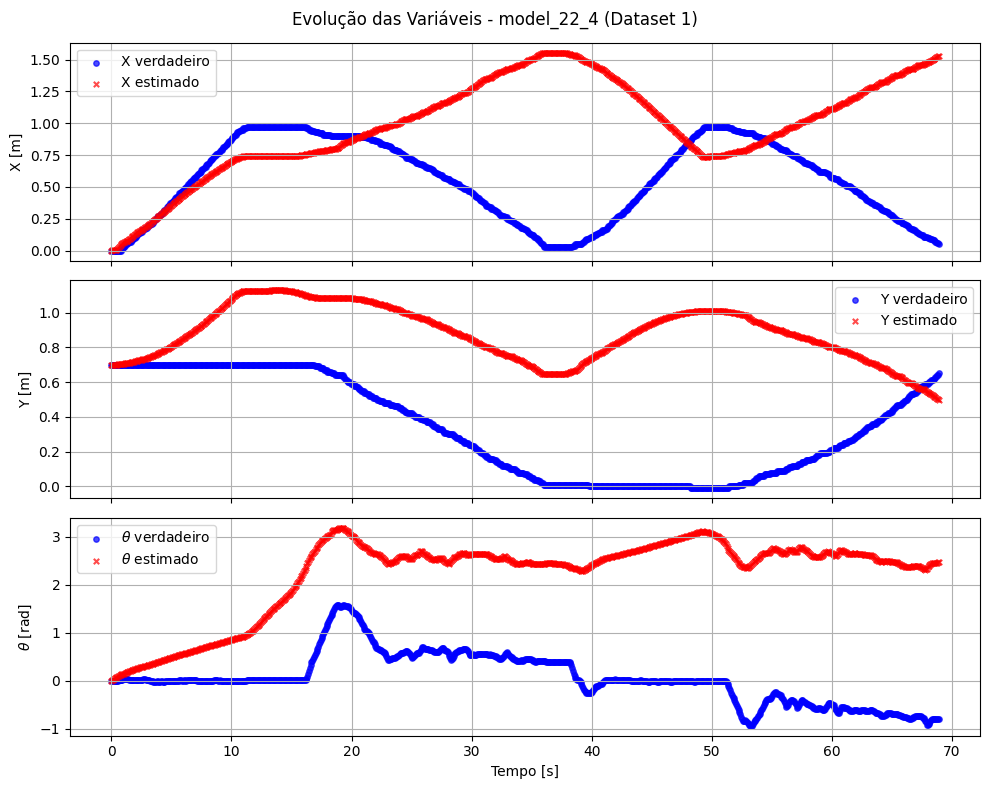

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_20_7 =====
R2_X = -1.5471, MSE_X = 0.259118
R2_Y = -1.0548, MSE_Y = 0.163790
R2_Theta = -10.5968, MSE_Theta = 3.278689


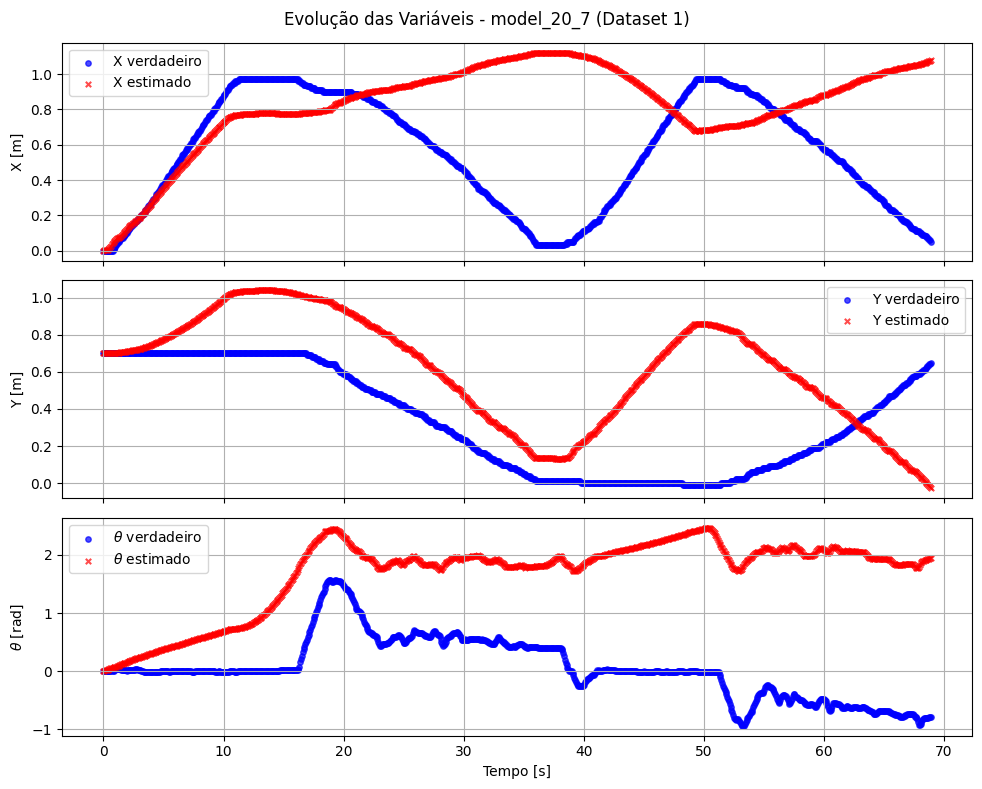

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_24_6 =====
R2_X = -1.6014, MSE_X = 0.264638
R2_Y = -3.3910, MSE_Y = 0.350010
R2_Theta = -8.3767, MSE_Theta = 2.651030


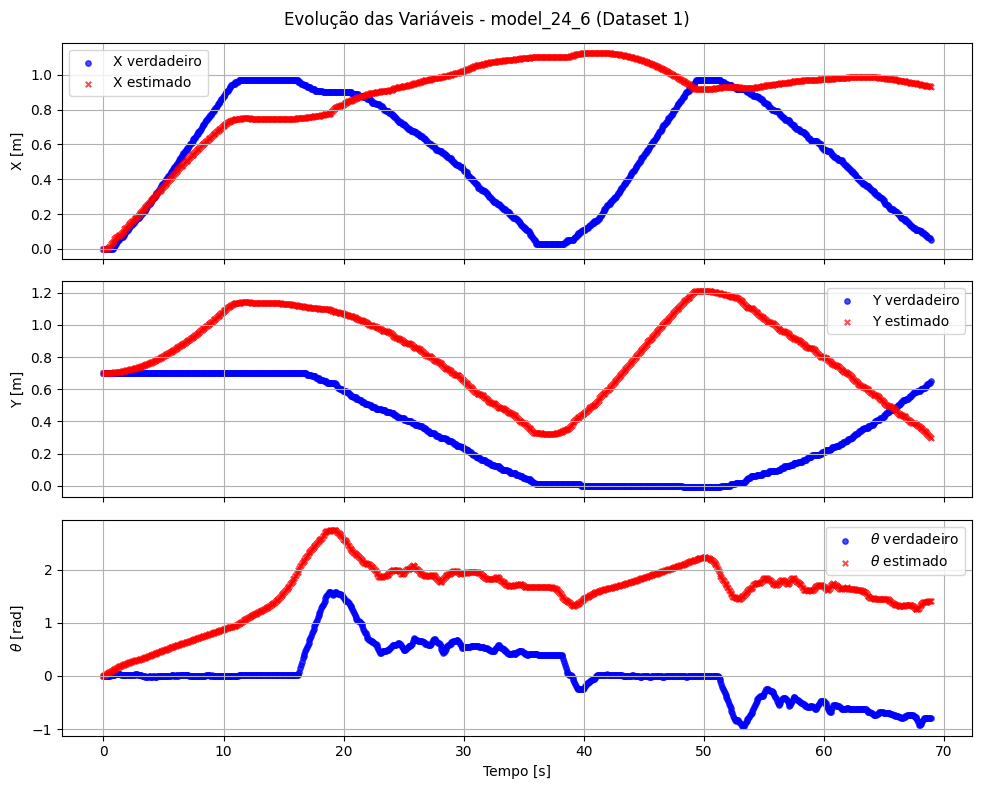

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== model_10_0 =====
R2_X = 0.8158, MSE_X = 0.018738
R2_Y = -2.1979, MSE_Y = 0.254904
R2_Theta = -0.5699, MSE_Theta = 0.443856


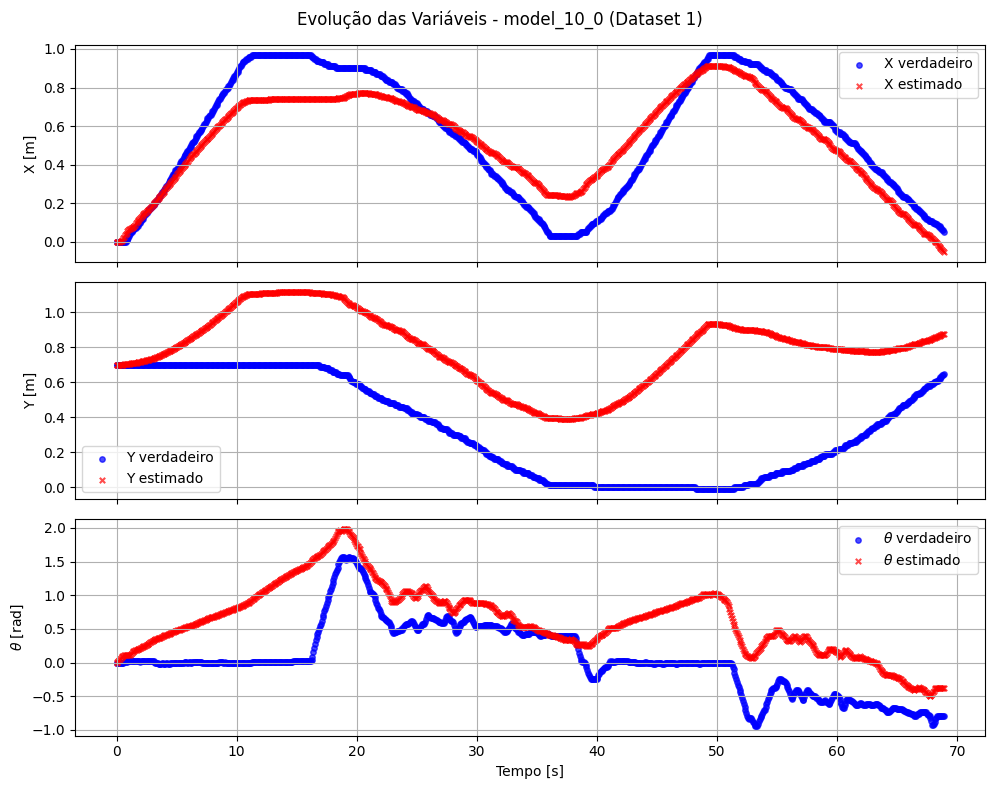



===== Avaliando Dataset 2 =====
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_22_4 =====
R2_X = -13.0103, MSE_X = 1.310059
R2_Y = -6.2272, MSE_Y = 0.378698
R2_Theta = -3.9195, MSE_Theta = 14.567948


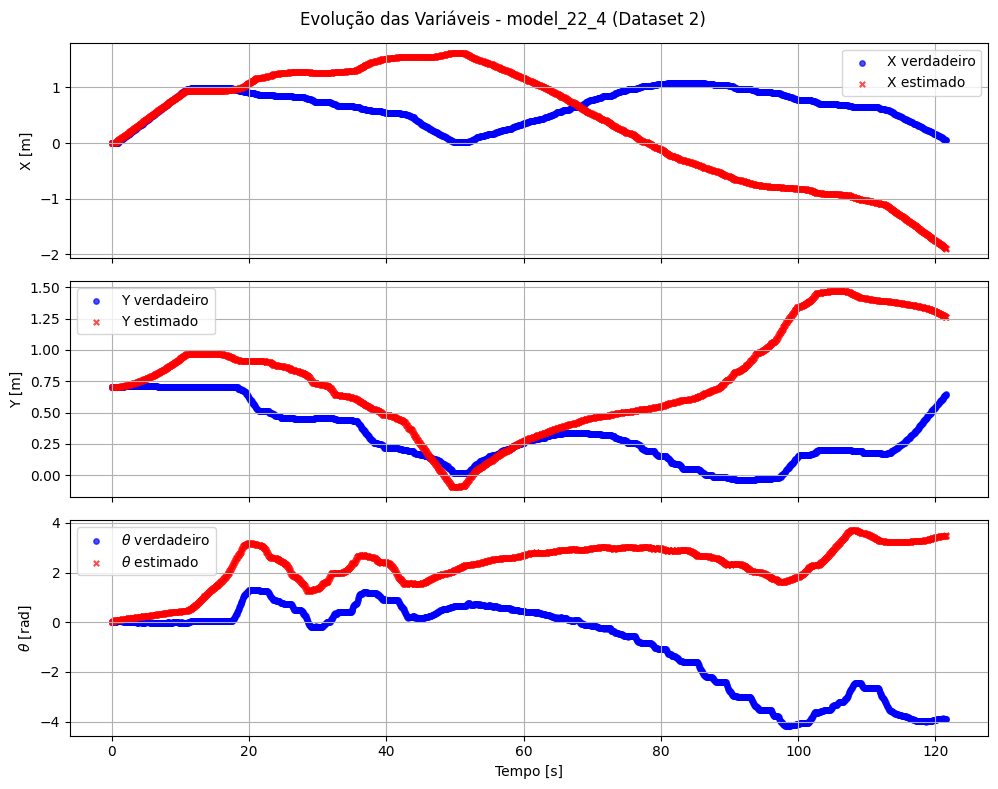

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

===== model_20_7 =====
R2_X = -0.9784, MSE_X = 0.184997
R2_Y = -8.1019, MSE_Y = 0.476930
R2_Theta = -0.0318, MSE_Theta = 3.055351


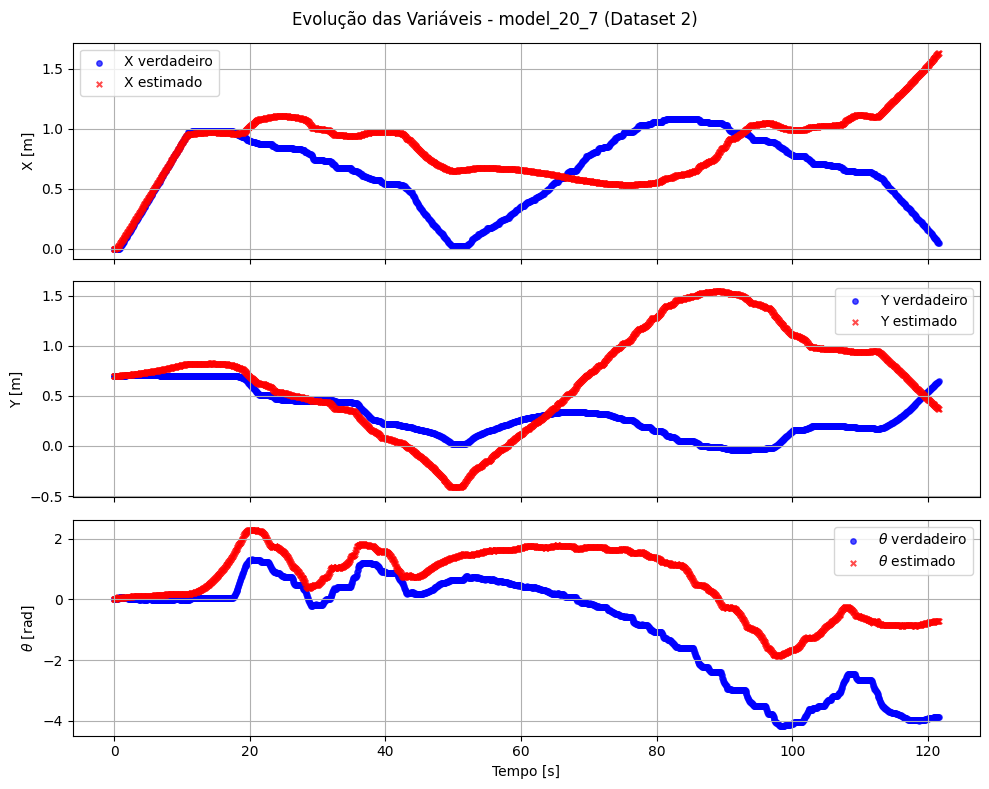

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

===== model_24_6 =====
R2_X = -3.0156, MSE_X = 0.375483
R2_Y = -30.2764, MSE_Y = 1.638855
R2_Theta = -1.2329, MSE_Theta = 6.612154


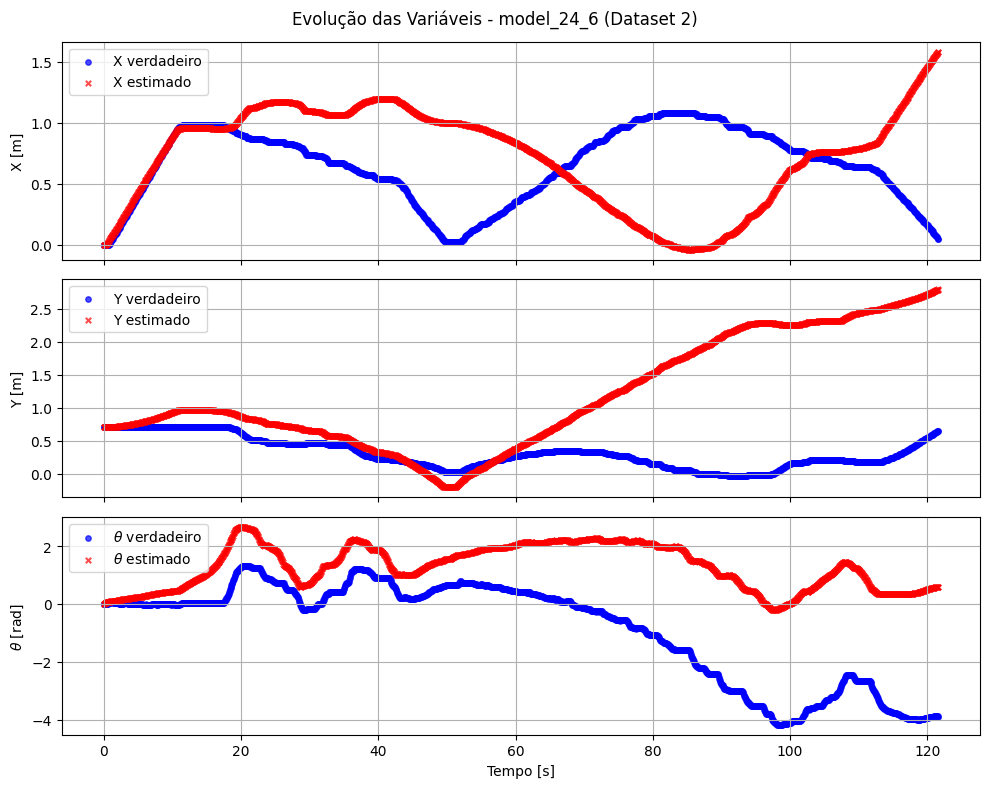

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

===== model_10_0 =====
R2_X = -0.8742, MSE_X = 0.175249
R2_Y = -57.0939, MSE_Y = 3.044068
R2_Theta = -2.5327, MSE_Theta = 10.461157


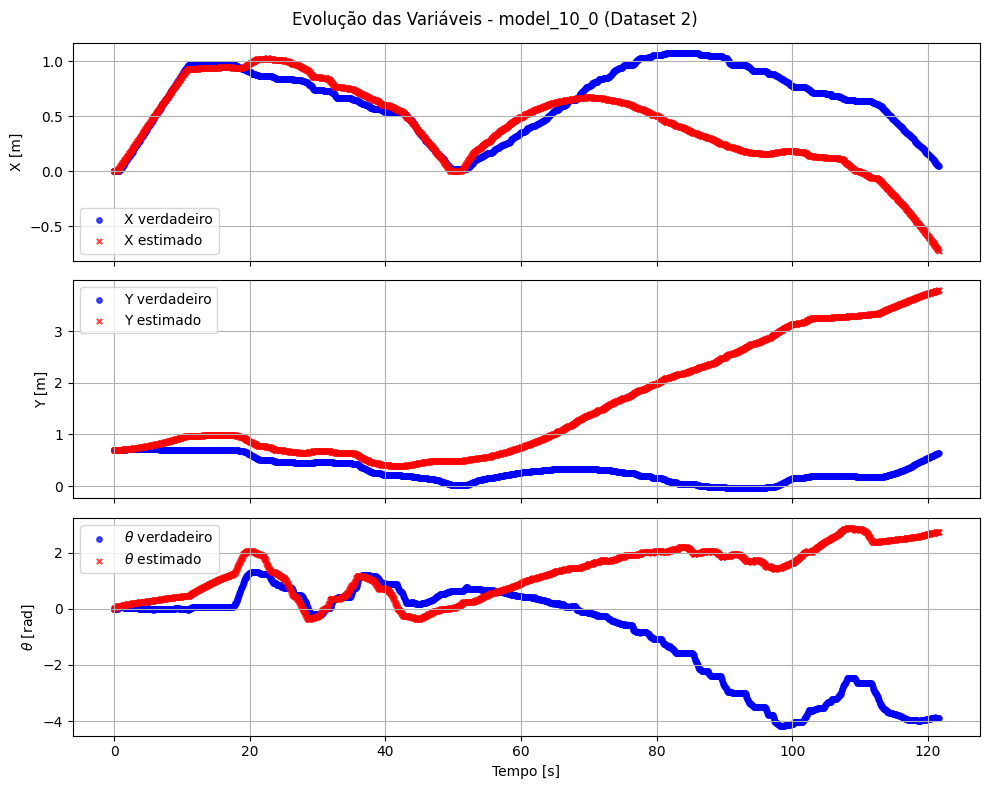



===== Avaliando Dataset 3 =====
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== model_22_4 =====
R2_X = -0.2695, MSE_X = 0.101407
R2_Y = -1.3324, MSE_Y = 0.138191
R2_Theta = -3.2633, MSE_Theta = 1.708528


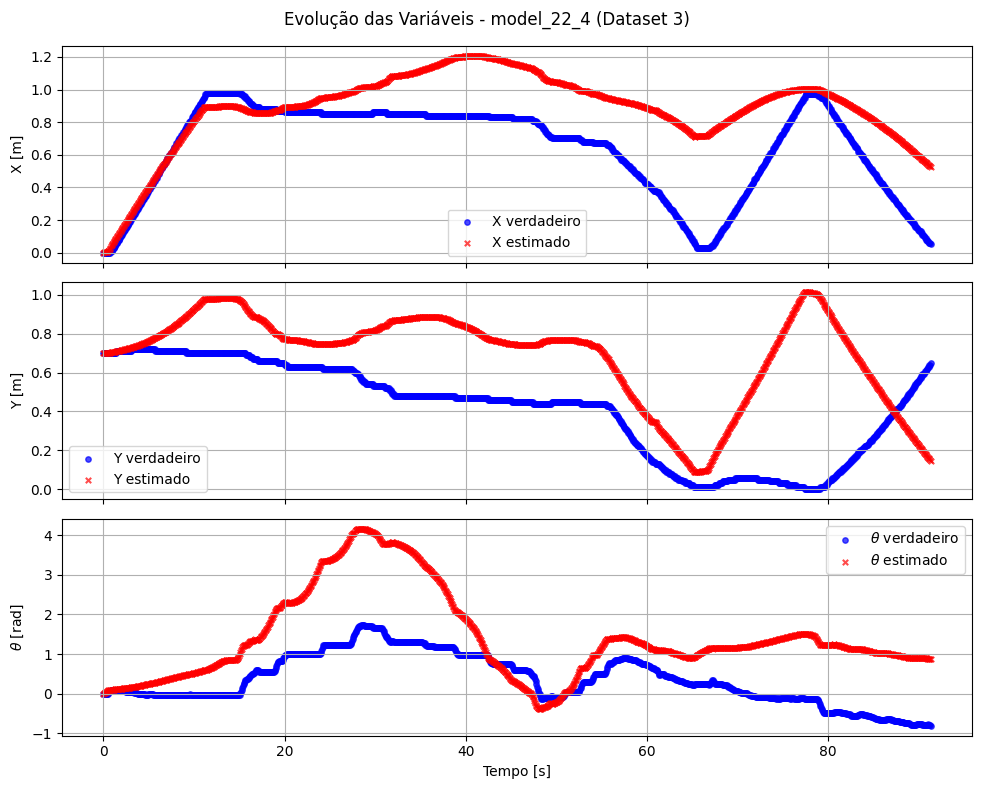

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== model_20_7 =====
R2_X = 0.6825, MSE_X = 0.025358
R2_Y = -1.0866, MSE_Y = 0.123625
R2_Theta = -0.7664, MSE_Theta = 0.707885


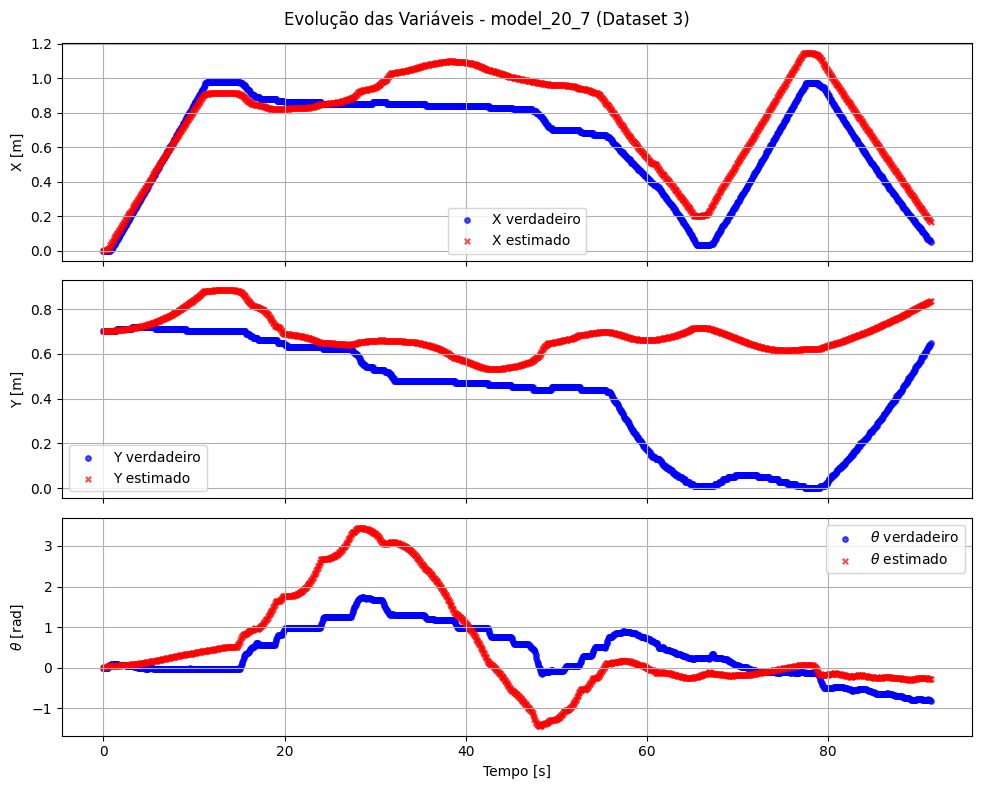

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

===== model_24_6 =====
R2_X = 0.2161, MSE_X = 0.062618
R2_Y = -2.1163, MSE_Y = 0.184634
R2_Theta = -2.0725, MSE_Theta = 1.231318


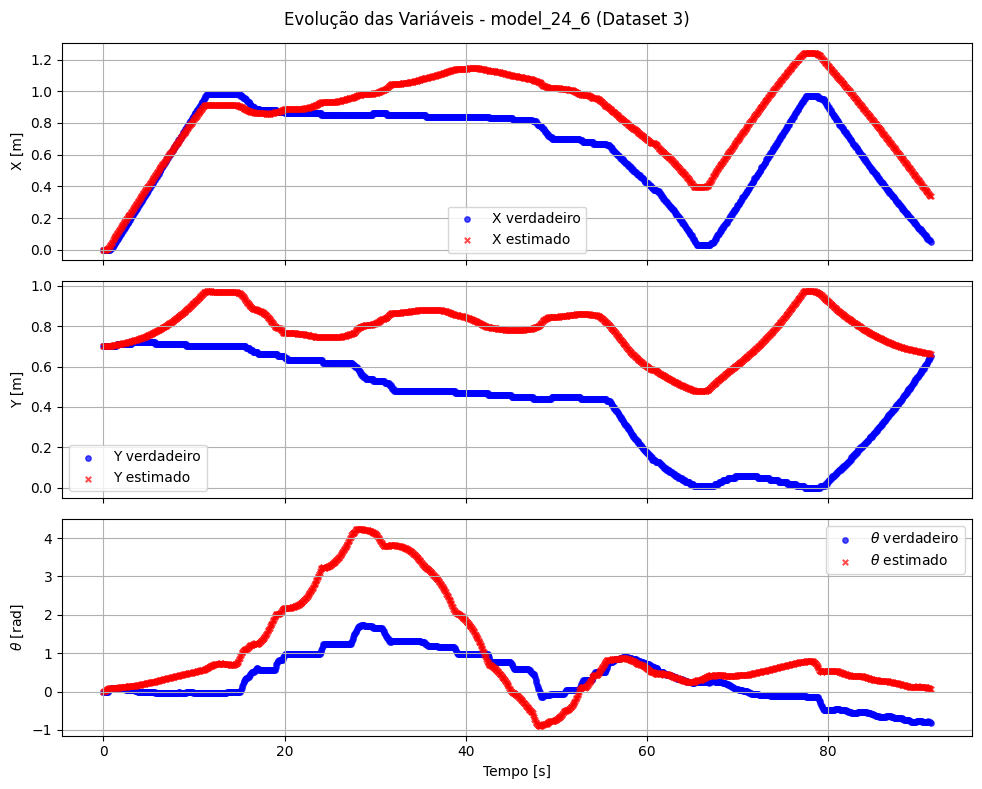

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_10_0 =====
R2_X = 0.4753, MSE_X = 0.041910
R2_Y = -3.7191, MSE_Y = 0.279598
R2_Theta = -2.8963, MSE_Theta = 1.561447


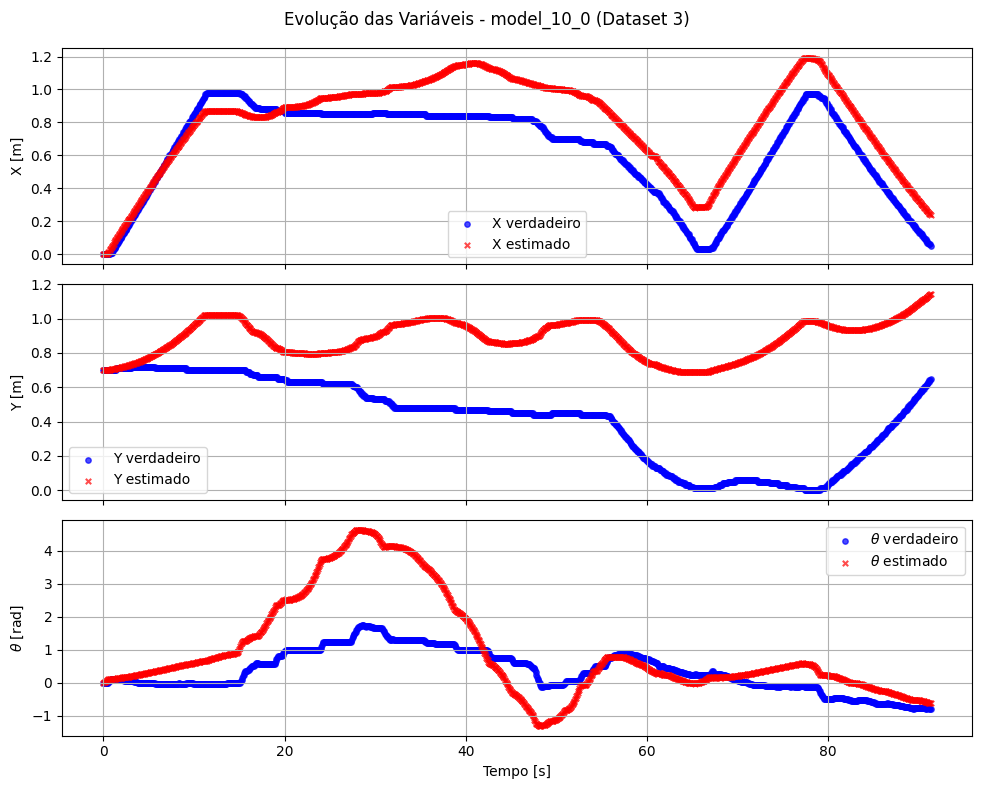



===== Avaliando Dataset 4 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

===== model_22_4 =====
R2_X = -7.1988, MSE_X = 0.763859
R2_Y = -4.9463, MSE_Y = 0.439911
R2_Theta = -22.2350, MSE_Theta = 7.736503


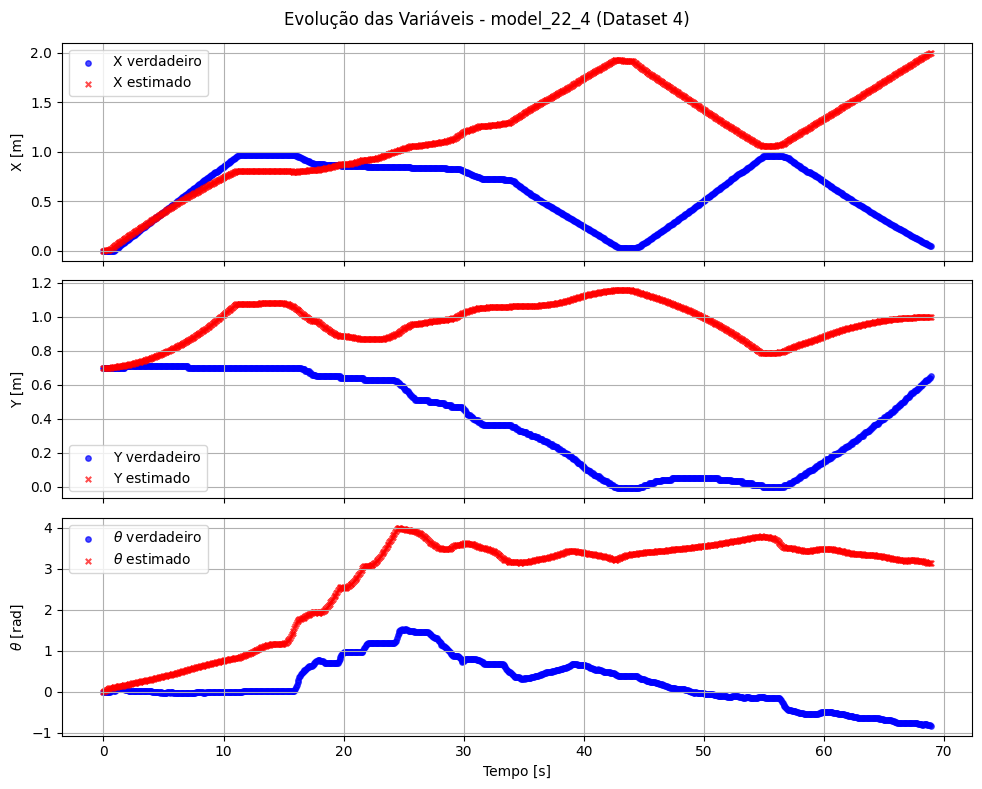

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

===== model_20_7 =====
R2_X = -6.2885, MSE_X = 0.679046
R2_Y = -0.4202, MSE_Y = 0.105066
R2_Theta = -13.9472, MSE_Theta = 4.976918


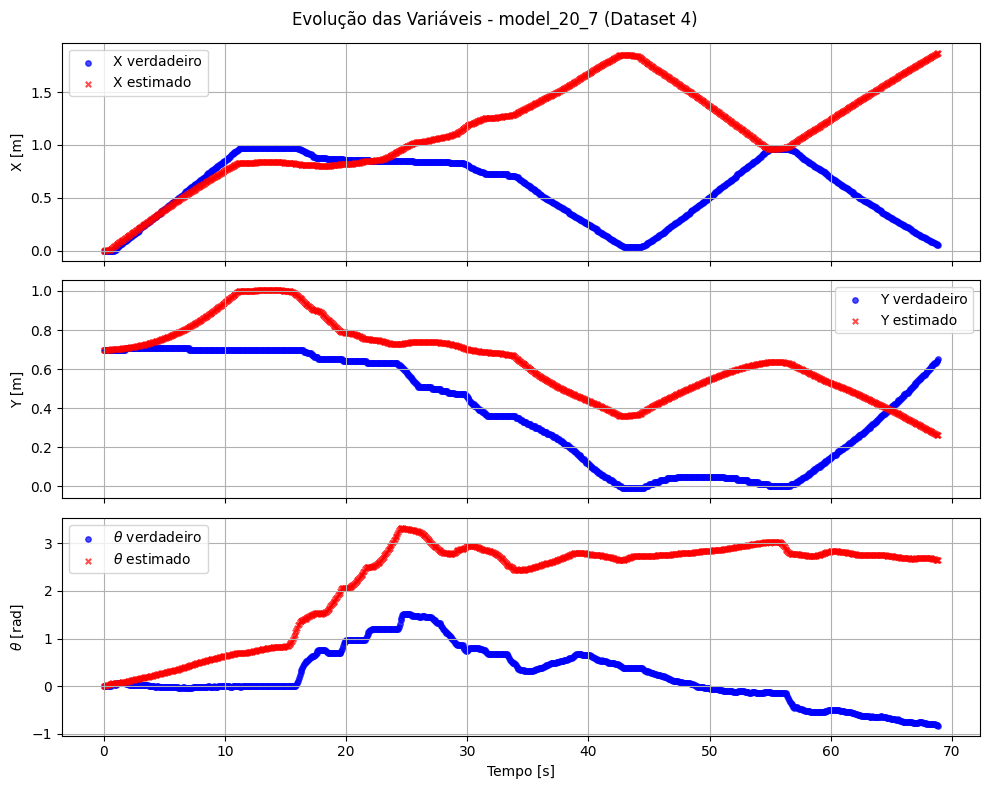

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

===== model_24_6 =====
R2_X = -6.7074, MSE_X = 0.718072
R2_Y = -3.8262, MSE_Y = 0.357046
R2_Theta = -18.9204, MSE_Theta = 6.632854


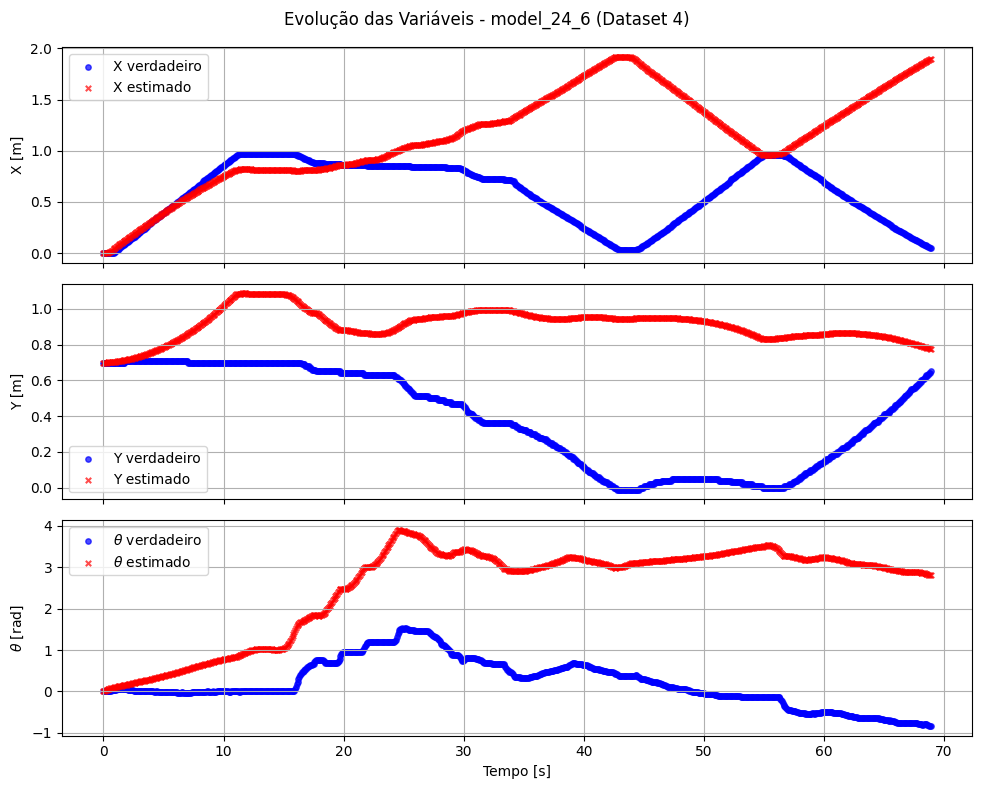

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

===== model_10_0 =====
R2_X = -6.7892, MSE_X = 0.725692
R2_Y = -6.9112, MSE_Y = 0.585281
R2_Theta = -21.2866, MSE_Theta = 7.420709


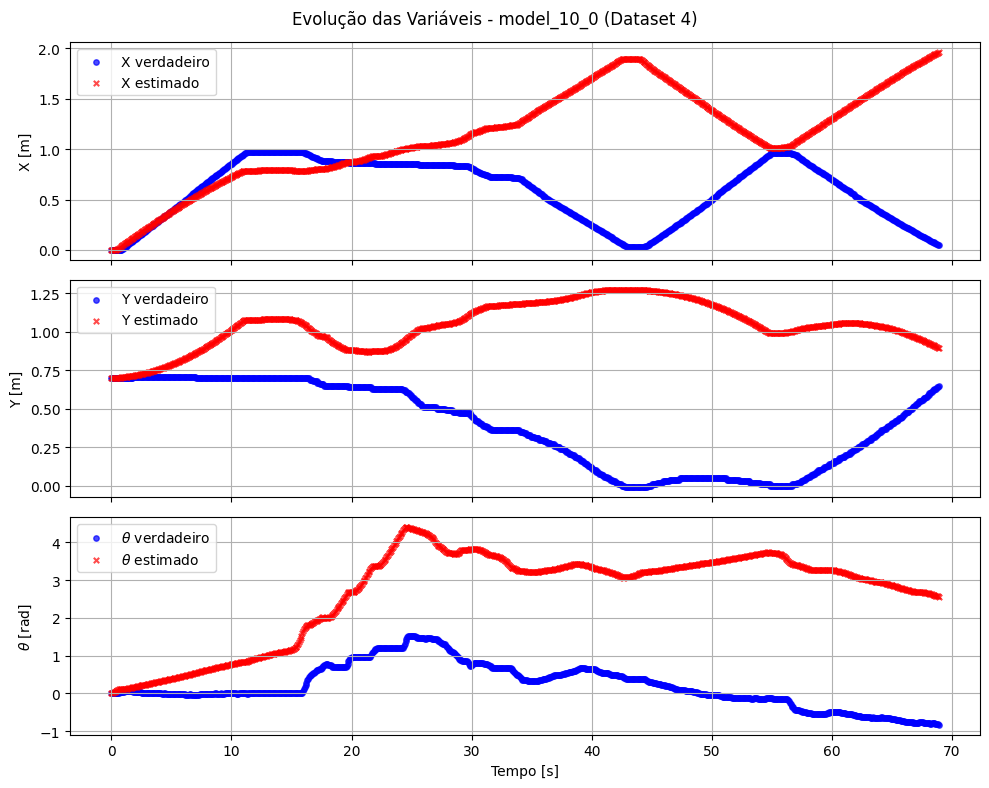

In [18]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------
# RECONSTRUÇÃO E AVALIAÇÃO
# -------------------------

results = []  # lista para armazenar métricas

# Correção: iteração simultânea deve usar zip()
for i, (NormDataset, Dataset) in enumerate(zip(NormDatasets, Datasets)):
    x_test, y_test = CreateSequences(NormDataset[PREDICTORS], NormDataset[TARGET], TIME_STEPS)
    Wd_We_true = OUT_SCALER.inverse_transform(y_test)

    X_true = Dataset["X"].values
    Y_true = Dataset["Y"].values
    Theta_true = Dataset["Theta"].values

    print(f"\n\n===== Avaliando Dataset {i+1} =====")

    for idx, ModelConf in ModelsConfs.iterrows():
        n = int(ModelConf["Neurons"])
        Name = ModelConf["model"]

        # --- Carrega pesos do modelo ---
        Wf = [np.array(w) for w in ast.literal_eval(ModelConf["Wf"])]

        model = keras.models.Sequential([
            keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
            keras.layers.SimpleRNN(n, activation="tanh"),
            keras.layers.Dense(OUTPUT_SIZE, activation="linear")
        ])
        model.set_weights(Wf)

        # --- Faz predição ---
        Wd_We_pred = OUT_SCALER.inverse_transform(model.predict(x_test))

        # --- Extrai velocidades previstas ---
        Wd_pred = Wd_We_pred[:, 0]   # ωd (roda direita)
        We_pred = Wd_We_pred[:, 1]   # ωe (roda esquerda)

        # --- Calcula odometria estimada ---
        X_est, Y_est, Theta_est = Odometry(Wd_pred, We_pred)

        # Garante que os tamanhos batem
        min_len = min(len(X_true), len(X_est))
        X_true, Y_true, Theta_true = X_true[:min_len], Y_true[:min_len], Theta_true[:min_len]
        X_est, Y_est, Theta_est = X_est[:min_len], Y_est[:min_len], Theta_est[:min_len]

        # --- Cálculo das métricas ---
        r2_x = r2_score(X_true, X_est)
        r2_y = r2_score(Y_true, Y_est)
        r2_theta = r2_score(Theta_true, Theta_est)

        mse_x = mean_squared_error(X_true, X_est)
        mse_y = mean_squared_error(Y_true, Y_est)
        mse_theta = mean_squared_error(Theta_true, Theta_est)

        print(f"\n===== {Name} =====")
        print(f"R2_X = {r2_x:.4f}, MSE_X = {mse_x:.6f}")
        print(f"R2_Y = {r2_y:.4f}, MSE_Y = {mse_y:.6f}")
        print(f"R2_Theta = {r2_theta:.4f}, MSE_Theta = {mse_theta:.6f}")

        # --- Armazena resultados ---
        results.append({
            "Dataset": i + 1,
            "Model": Name,
            "Neurons": n,
            "R2_X": r2_x, "MSE_X": mse_x,
            "R2_Y": r2_y, "MSE_Y": mse_y,
            "R2_Theta": r2_theta, "MSE_Theta": mse_theta
        })

        # --- Gera gráfico ---
        PlotTrajectoryEvolution(
            X_true, Y_true, Theta_true,
            X_est, Y_est, Theta_est,
            f"Evolução das Variáveis - {Name} (Dataset {i+1})"
        )
        
results_df = pd.DataFrame(results)
results_df.to_excel("Odometry.xlsx")
